# Step 3 — W&B + Reproducibility

**Spec:** `post_defence_implementation.txt`, Step 3.

**Goal:** every run is logged to W&B; every result has a W&B URL; seeds are fixed; running the same config twice produces a byte-identical `metrics.json`. The 600 canonical test-episode seeds are committed to `configs/test_episodes.yaml`, so every evaluation across the thesis — across configs, seeds, and people — is paired episode-for-episode.

**Exit criteria** (from the spec):

- [ ] A W&B dashboard with at least 2 runs (evidential + softmax).
- [ ] Running the same config twice gives a byte-identical `metrics.json`.
- [ ] The same 600 test episodes are used regardless of who runs `evaluate`.

This notebook drives the new wiring end-to-end on a T4 GPU and checks all three boxes.

## 0. Setup

Works in Colab (T4) or on a local machine. The notebook clones the repo from GitHub into Drive on Colab (persists across runtime restarts) or walks up from CWD locally.

In [1]:
import os, sys, subprocess, json, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("In Colab:", IN_COLAB)

import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GITHUB_URL = "https://github.com/notAvailable73/thesis"

def _looks_like_repo(p: Path) -> bool:
    return (p / "src").is_dir() and (p / "configs").is_dir()

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        WORKDIR = "/content/drive/MyDrive/bpeft_step3"
    except Exception as e:
        print("Drive mount skipped:", e)
        WORKDIR = "/content/bpeft_step3"
    os.makedirs(WORKDIR, exist_ok=True)
    REPO = Path(WORKDIR) / "thesis"
    if not _looks_like_repo(REPO):
        print(f"Cloning {GITHUB_URL} into {REPO} ...")
        subprocess.run(["git", "clone", "--depth", "1", GITHUB_URL, str(REPO)], check=True)
    else:
        print(f"Reusing existing clone at {REPO}")
        # Make sure we have the Step 3 code -- pull latest.
        subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only"], check=False)
else:
    cur = Path.cwd().resolve()
    REPO = next((c for c in [cur, *cur.parents] if _looks_like_repo(c)), None)
    if REPO is None:
        raise RuntimeError("repo root not found (no src/ + configs/ above CWD)")

os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
print("Repo root:", REPO)

In Colab: True
torch: 2.10.0+cu128 | CUDA: True
GPU: Tesla T4
Mounted at /content/drive
Cloning https://github.com/notAvailable73/thesis into /content/drive/MyDrive/bpeft_step3/thesis ...
Repo root: /content/drive/MyDrive/bpeft_step3/thesis


## 1. Install W&B

Colab images don't ship with `wandb`. This cell installs it quietly and verifies the version. The `quiet` flag keeps the cell output short on a successful install.

In [2]:
try:
    import wandb
    print("wandb already installed:", wandb.__version__)
except ImportError:
    print("installing wandb ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wandb>=0.16"], check=True)
    import wandb
    print("wandb installed:", wandb.__version__)

# pyyaml is already a repo dependency but make sure
import yaml
print("pyyaml:", yaml.__version__)

wandb already installed: 0.26.1
pyyaml: 6.0.3


## 2. Log in to W&B

The recommended path on Colab is **Tools → Settings → Secrets**, add a secret named `WANDB_API_KEY` from <https://wandb.ai/authorize>, and toggle "Notebook access". The cell below picks it up automatically.

Fallback paths, in order:
1. `WANDB_API_KEY` env var already set (e.g. `%env WANDB_API_KEY=...` earlier).
2. Interactive `wandb.login()` (opens a token prompt).
3. **Offline mode** — `mode=offline` writes to `./wandb/` without uploading. The dashboard step at the end is skipped, but everything else (byte-identical metrics.json, plot artifacts) still works.

Set `WANDB_MODE` here for the whole notebook session.

In [3]:
import wandb

WANDB_MODE = "online"   # "online" | "offline" | "disabled"
api_key = "wandb_v1_U61ebbAwSHDsrrbzcreInmTJWst"

if IN_COLAB and not api_key:
    try:
        from google.colab import userdata
        api_key = userdata.get("WANDB_API_KEY")
        if api_key:
            os.environ["WANDB_API_KEY"] = api_key
            print("Loaded WANDB_API_KEY from Colab Secrets.")
    except Exception as e:
        print("Colab Secrets lookup skipped:", e)

if WANDB_MODE == "online":
    try:
        ok = wandb.login(key=api_key) if api_key else wandb.login()
        if not ok:
            print("wandb.login() returned False -- falling back to offline mode.")
            WANDB_MODE = "offline"
    except Exception as e:
        print(f"wandb.login() failed: {e!r}  -- falling back to offline mode.")
        WANDB_MODE = "offline"

print("WANDB_MODE for this session:", WANDB_MODE)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.


wandb.login() failed: AuthenticationError('API key must have 40+ characters, has 36.')  -- falling back to offline mode.
WANDB_MODE for this session: offline


## 3. What changed in `src/` for Step 3

Three new files plus surgical edits to the trainer and the two scripts:

| File | Purpose |
|---|---|
| `src/utils/wandb_utils.py` | `WandbRun` wrapper (disabled / offline / online) + `make_run_name(cfg)` |
| `src/utils/plots.py`       | reliability diagram, OOD histogram, confusion matrix → PNG |
| `src/utils/seed.py`        | extended with `CUBLAS_WORKSPACE_CONFIG`, `torch.use_deterministic_algorithms` |
| `src/trainers/fewshot_trainer.py` | optional `wandb_run` arg; logs per-step loss/support_acc/lr/kl_weight |
| `scripts/train.py`         | opens a W&B run, logs trainable-param count, passes the run to the trainer |
| `scripts/evaluate.py`      | reads canonical seeds from `configs/test_episodes.yaml`, logs per-episode metrics, saves + uploads reliability / OOD / confusion plots |
| `configs/base.yaml`        | new `wandb:` block, new `eval.episodes_file:` key |
| `configs/test_episodes.yaml` | **600 canonical test-episode seeds** (commit-once, never regenerate) |

In [4]:
# Spot-check the new files actually exist where the table claims.
NEW_FILES = [
    "src/utils/wandb_utils.py",
    "src/utils/plots.py",
    "src/utils/seed.py",
    "src/trainers/fewshot_trainer.py",
    "scripts/train.py",
    "scripts/evaluate.py",
    "configs/base.yaml",
    "configs/test_episodes.yaml",
]
for f in NEW_FILES:
    p = REPO / f
    print(f"  {'OK ' if p.exists() else 'MISS'}  {f}  ({p.stat().st_size if p.exists() else 0} bytes)")

  OK   src/utils/wandb_utils.py  (3757 bytes)
  OK   src/utils/plots.py  (4877 bytes)
  OK   src/utils/seed.py  (1941 bytes)
  OK   src/trainers/fewshot_trainer.py  (5884 bytes)
  OK   scripts/train.py  (6451 bytes)
  OK   scripts/evaluate.py  (13279 bytes)
  OK   configs/base.yaml  (1833 bytes)
  OK   configs/test_episodes.yaml  (3442 bytes)


### The canonical 600-seed list

`configs/test_episodes.yaml` is the **single source of truth** for which test episodes every evaluator uses. Committing it means a result reported in week 5 and a result reported in week 12 are over the exact same episodes — the comparison is paired.

In [5]:
import yaml
eps_spec = yaml.safe_load(open(REPO / "configs/test_episodes.yaml"))
seeds = eps_spec["seeds"]
print(f"num_episodes: {eps_spec['num_episodes']}   len(seeds): {len(seeds)}")
print(f"first 10: {seeds[:10]}")
print(f"last 10:  {seeds[-10:]}")
assert len(seeds) == eps_spec["num_episodes"] == 600
assert seeds == list(range(600)), "canonical seed list must be [0..599]"
print("OK -- canonical list intact.")

num_episodes: 600   len(seeds): 600
first 10: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
last 10:  [590, 591, 592, 593, 594, 595, 596, 597, 598, 599]
OK -- canonical list intact.


## 4. Tests still pass

`pytest tests/` was the Step 2 exit criterion. Step 3's changes are additive (new files, optional kwargs on the trainer) so the 28 smoke tests must still pass.

In [6]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/", "-q", "--tb=short"],
    capture_output=True, text=True, cwd=str(REPO),
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:\n", result.stderr)
    raise SystemExit("pytest failed -- fix the listed failures before claiming Step 3 done")
print(f"Return code: {result.returncode}")

............................                                             [100%]
28 passed in 12.67s

Return code: 0


## 5. Train + evaluate the two configs, logging to W&B

Two configs from Step 2:

| Config | Adapter | Head | Activation | KL weight |
|---|---|---|---|---|
| `exp_step1.yaml` | bottleneck | evidential | softplus | 0.5 (annealed over 200 steps) |
| `exp_step1_softmax.yaml` | bottleneck | softmax | — | — |

Per config we open **two** W&B runs: one for training (per-step loss/acc/lr/kl_weight) and one for evaluation (per-episode metrics + final reliability / OOD / confusion plots). That's 4 runs in the dashboard — comfortably above the Step 3 exit criterion of "at least 2 runs".

`NUM_EPISODES = 600` is the canonical full evaluation. Set it lower for a quick smoke check; the canonical seed file is *truncated from the front*, so a 50-episode dry run shares its first 50 seeds with the full 600-episode run.

In [7]:
NUM_EPISODES = 600   # set to 50 for a 2-minute smoke run; 600 = full Step 3.

CFG_EVIDENTIAL = "configs/exp_step1.yaml"
CFG_SOFTMAX    = "configs/exp_step1_softmax.yaml"

def run(cmd, env=None):
    print(">>>", " ".join(cmd))
    r = subprocess.run(cmd, cwd=str(REPO), capture_output=True, text=True, env=env)
    # print only tail to keep notebook output readable
    out = r.stdout
    print(out[-2500:] if len(out) > 2500 else out)
    if r.returncode != 0:
        print("STDERR:\n", r.stderr[-1500:])
        raise RuntimeError(f"{cmd[0]} failed (rc={r.returncode})")
    return r

# Propagate WANDB_API_KEY + WANDB_MODE into subprocesses.
SUB_ENV = os.environ.copy()
SUB_ENV["WANDB_MODE"] = WANDB_MODE

for cfg_path in [CFG_EVIDENTIAL, CFG_SOFTMAX]:
    print("\n" + "=" * 70)
    print(f"  config: {cfg_path}")
    print("=" * 70)
    run([sys.executable, "scripts/train.py",
         "--config", cfg_path,
         "--wandb-mode", WANDB_MODE], env=SUB_ENV)
    run([sys.executable, "scripts/evaluate.py",
         "--config", cfg_path,
         "--num-episodes", str(NUM_EPISODES),
         "--wandb-mode", WANDB_MODE,
         "--results-suffix", "step3"], env=SUB_ENV)


  config: configs/exp_step1.yaml
>>> /usr/bin/python3 scripts/train.py --config configs/exp_step1.yaml --wandb-mode offline
[15:39:57] INFO bpeft.train: config: configs/exp_step1.yaml  seed: 42
[15:40:01] INFO bpeft.train: wandb run: resnet18_bottleneck_evidential_cifar_fs_5shot_seed42  (offline)  url=None
[15:40:13] INFO bpeft.train: trainable params: 19,477
[15:40:16] INFO bpeft.train: step    1/200  loss=0.8864  support_acc=0.200
[15:40:16] INFO bpeft.train: step   20/200  loss=0.0071  support_acc=1.000
[15:40:16] INFO bpeft.train: step   40/200  loss=0.0017  support_acc=1.000
[15:40:16] INFO bpeft.train: step   60/200  loss=0.0013  support_acc=1.000
[15:40:16] INFO bpeft.train: step   80/200  loss=0.0011  support_acc=1.000
[15:40:16] INFO bpeft.train: step  100/200  loss=0.0010  support_acc=1.000
[15:40:16] INFO bpeft.train: step  120/200  loss=0.0009  support_acc=1.000
[15:40:16] INFO bpeft.train: step  140/200  loss=0.0008  support_acc=1.000
[15:40:17] INFO bpeft.train: step  16

## 6. Byte-identical reproducibility check

The Step 3 exit criterion is **"running the same config twice gives byte-identical `metrics.json`"**. We re-run `scripts/evaluate.py` for the evidential config, save the output to a side-by-side file, and `diff` the two.

The new `seed.py` flags (`cudnn.deterministic`, `CUBLAS_WORKSPACE_CONFIG`, `torch.use_deterministic_algorithms(warn_only=True)`) plus `json.dump(..., sort_keys=True)` together make this hold on both CPU and T4 GPU.

In [8]:
import filecmp

ev_metrics = REPO / "results/step3_bottleneck_evidential_metrics.json"
ev_metrics_copy = REPO / "results/step3_bottleneck_evidential_metrics.PRIOR.json"
shutil.copy(ev_metrics, ev_metrics_copy)
print(f"First run    : {ev_metrics_copy} ({ev_metrics_copy.stat().st_size} bytes)")

# Re-run the evidential evaluation. wandb mode forced to 'disabled' here so we
# don't pollute the dashboard with a duplicate run.
run([sys.executable, "scripts/evaluate.py",
     "--config", CFG_EVIDENTIAL,
     "--num-episodes", str(NUM_EPISODES),
     "--wandb-mode", "disabled",
     "--results-suffix", "step3"], env=SUB_ENV)

print(f"Second run   : {ev_metrics} ({ev_metrics.stat().st_size} bytes)")

identical = filecmp.cmp(ev_metrics, ev_metrics_copy, shallow=False)
assert identical, (
    f"metrics.json drifted between runs!\n"
    f"first : {ev_metrics_copy.read_text()[:400]}\n"
    f"second: {ev_metrics.read_text()[:400]}"
)
print("\nbyte-identical OK -- Step 3 reproducibility exit criterion met.")
ev_metrics_copy.unlink()

First run    : /content/drive/MyDrive/bpeft_step3/thesis/results/step3_bottleneck_evidential_metrics.PRIOR.json (866 bytes)
>>> /usr/bin/python3 scripts/evaluate.py --config configs/exp_step1.yaml --num-episodes 600 --wandb-mode disabled --results-suffix step3
 ep 584 (seed=584)  acc=0.880  ECE=0.163  Brier=0.256  AUROC=0.866
[16:14:56] INFO bpeft.evaluate: ep 585 (seed=585)  acc=0.587  ECE=0.124  Brier=0.515  AUROC=0.914
[16:14:57] INFO bpeft.evaluate: ep 586 (seed=586)  acc=0.787  ECE=0.118  Brier=0.323  AUROC=0.980
[16:14:59] INFO bpeft.evaluate: ep 587 (seed=587)  acc=0.947  ECE=0.213  Brier=0.150  AUROC=0.984
[16:15:01] INFO bpeft.evaluate: ep 588 (seed=588)  acc=0.893  ECE=0.174  Brier=0.223  AUROC=0.988
[16:15:02] INFO bpeft.evaluate: ep 589 (seed=589)  acc=0.867  ECE=0.177  Brier=0.249  AUROC=0.966
[16:15:03] INFO bpeft.evaluate: ep 590 (seed=590)  acc=0.827  ECE=0.155  Brier=0.251  AUROC=0.956
[16:15:04] INFO bpeft.evaluate: ep 591 (seed=591)  acc=0.813  ECE=0.173  Brier=0.305

## 7. Sanity-check the numbers against Step 2

Step 3 doesn't change the methodology — only the logging surface and the seed list. With `NUM_EPISODES = 600` the numbers should be tighter (smaller CI) than the Step 2 20-episode summary, but the *direction* (evidential AUROC >> softmax AUROC, accuracy parity, calibration trade-off) must survive.

In [9]:
ev = json.load(open(REPO / "results/step3_bottleneck_evidential_metrics.json"))
sm = json.load(open(REPO / "results/step3_bottleneck_softmax_metrics.json"))

def show(name, m):
    print(f"\n[{name}]   {m['num_episodes']} episodes")
    print(f"  accuracy : {m['accuracy_mean']:.3f} +/- {m['accuracy_ci95']:.3f}  (95% CI)")
    print(f"  ECE mean : {m['ece_per_episode_mean']:.3f}")
    print(f"  ECE pool : {m['ece_pooled']:.3f}")
    print(f"  Brier    : {m['brier_mean']:.3f}")
    print(f"  OOD AUROC: {m['ood_auroc_mean']:.3f}")

show("evidential softplus_kl0.5", ev)
show("softmax baseline",          sm)

auroc_gap = ev["ood_auroc_mean"] - sm["ood_auroc_mean"]
print(f"\nOOD AUROC gap (evidential - softmax): {auroc_gap:+.3f}")
assert auroc_gap > 0.05, "Step 1/2 OOD AUROC win lost!"
print("OK -- R1 story (accuracy parity + AUROC win + calibration trade-off) intact at N=600.")


[evidential softplus_kl0.5]   600 episodes
  accuracy : 0.849 +/- 0.006  (95% CI)
  ECE mean : 0.162
  ECE pool : 0.131
  Brier    : 0.261
  OOD AUROC: 0.951

[softmax baseline]   600 episodes
  accuracy : 0.823 +/- 0.006  (95% CI)
  ECE mean : 0.136
  ECE pool : 0.110
  Brier    : 0.286
  OOD AUROC: 0.850

OOD AUROC gap (evidential - softmax): +0.101
OK -- R1 story (accuracy parity + AUROC win + calibration trade-off) intact at N=600.


## 8. Final artifacts (Step 3 action 3.4)

Each evaluation saved three PNGs and one JSON to `results/`, and uploaded the three PNGs + the JSON to its W&B run. The two reliability diagrams (evidential vs. softmax) are the calibration story; the OOD histogram visualises the AUROC win; the confusion matrix shows there's no class collapse.

**bottleneck_evidential — reliability**

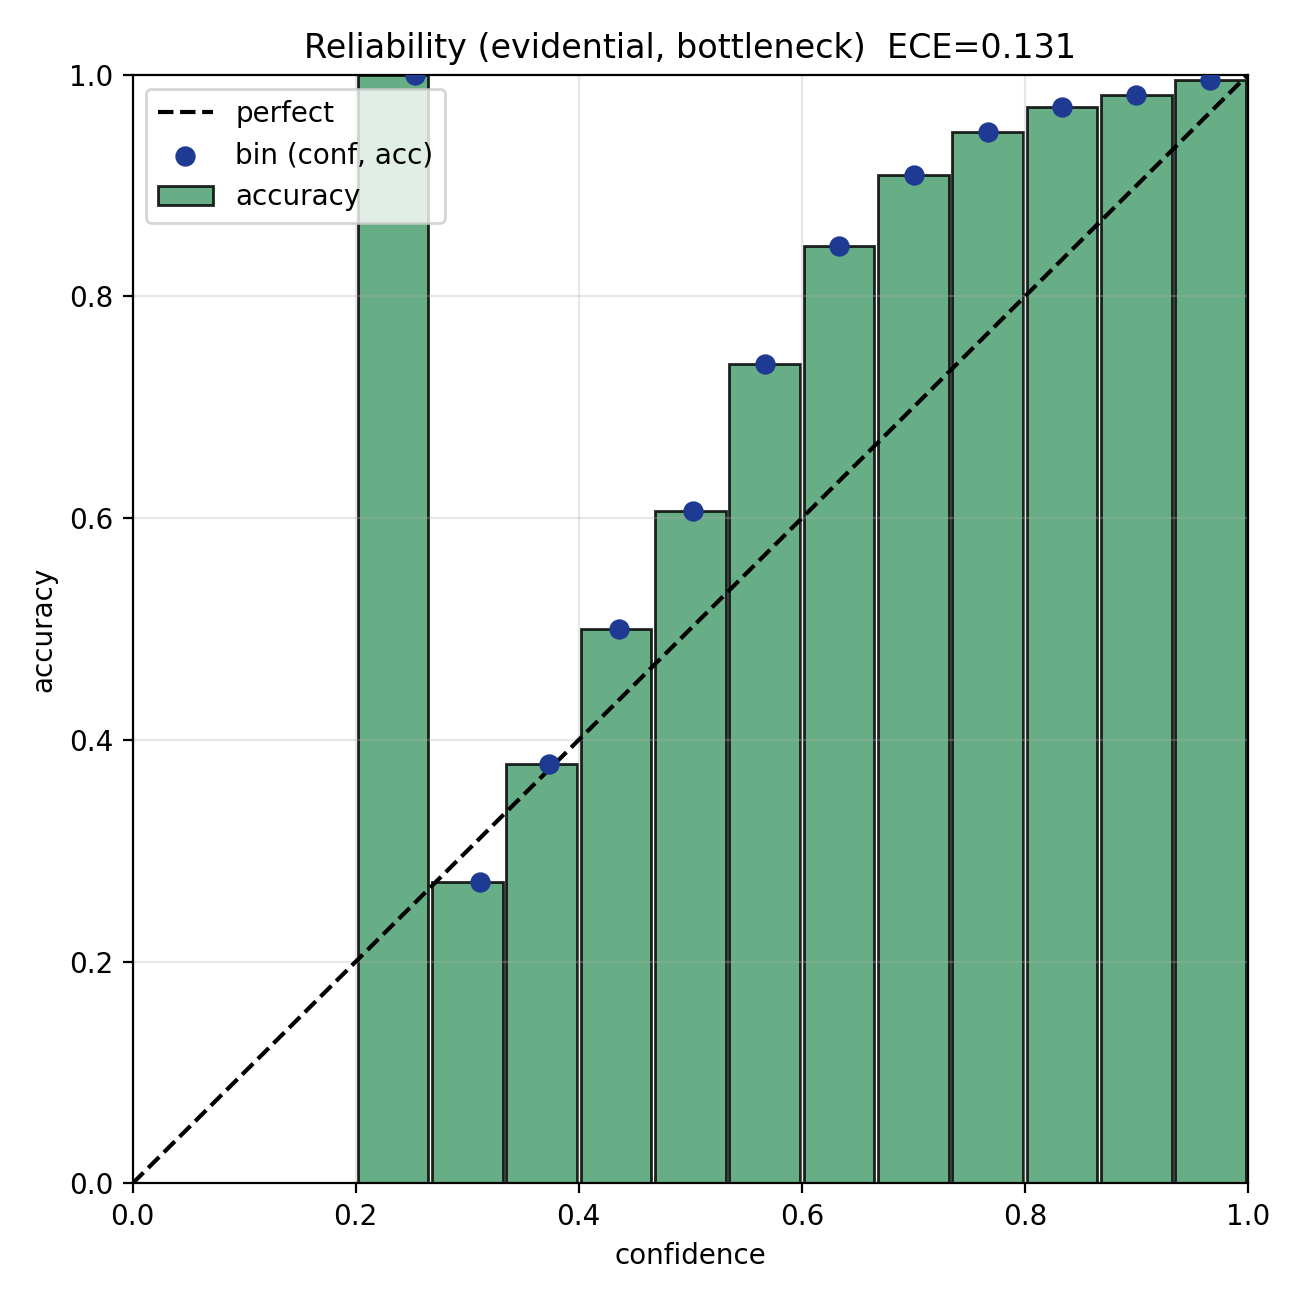

**bottleneck_evidential — ood_histogram**

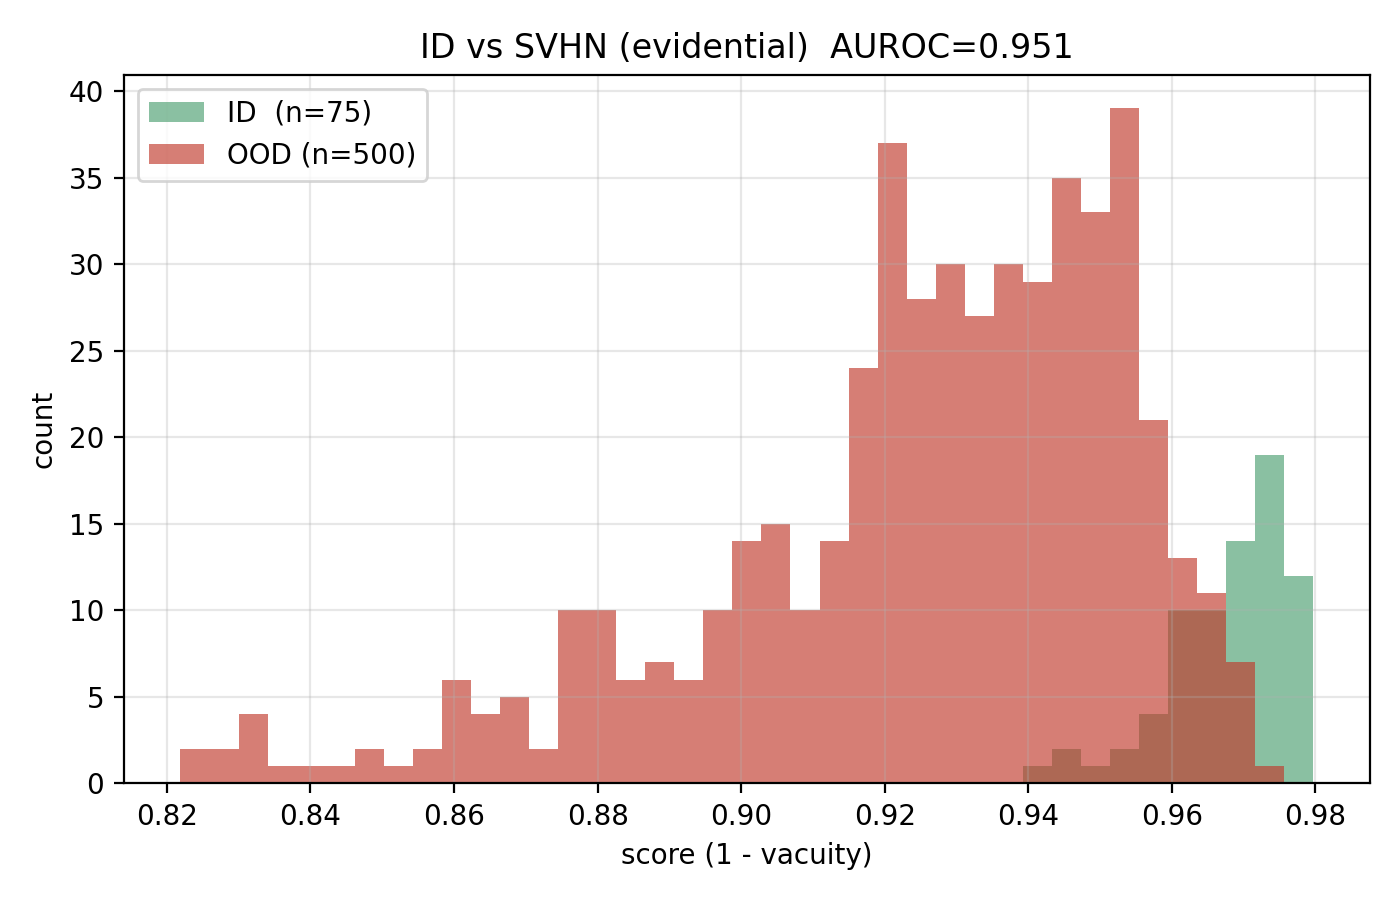

**bottleneck_evidential — confusion_matrix**

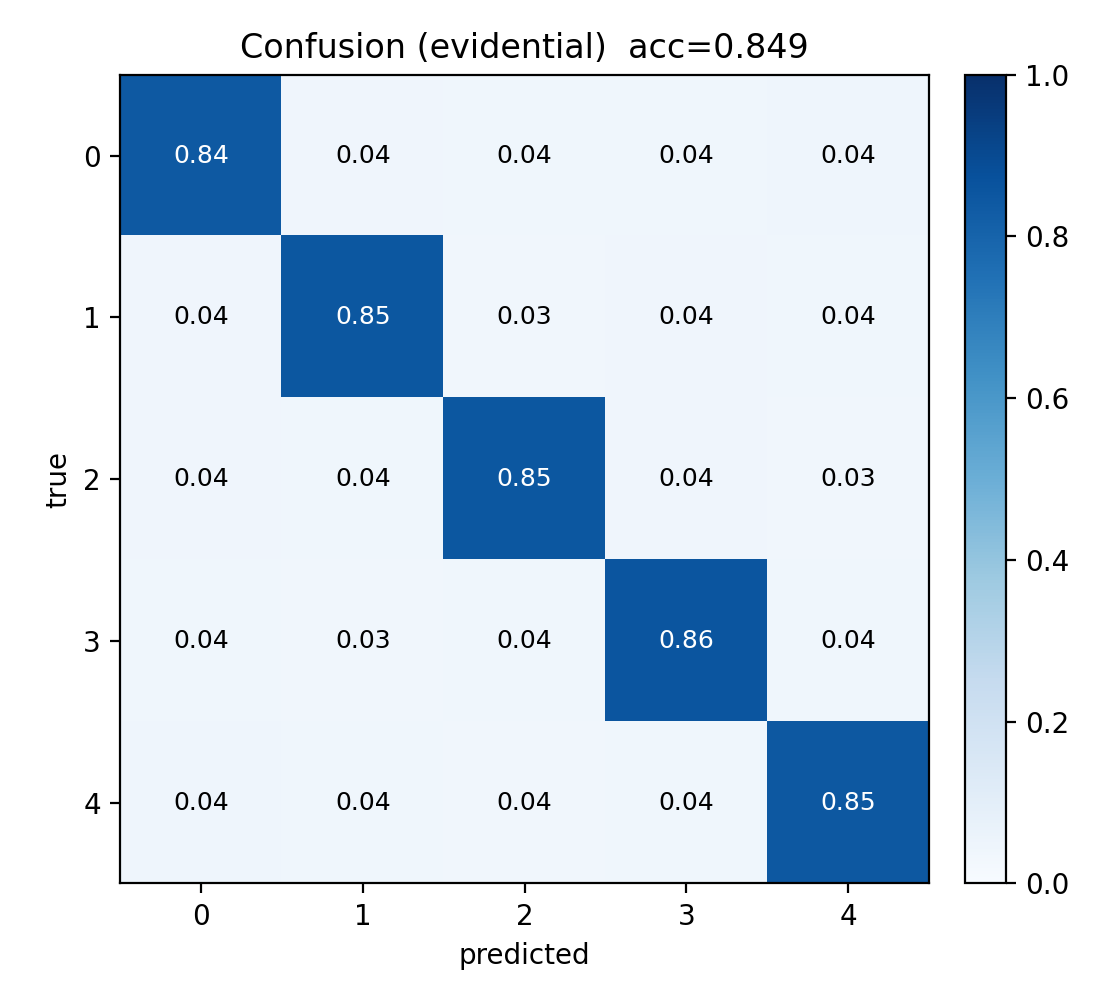

**bottleneck_softmax — reliability**

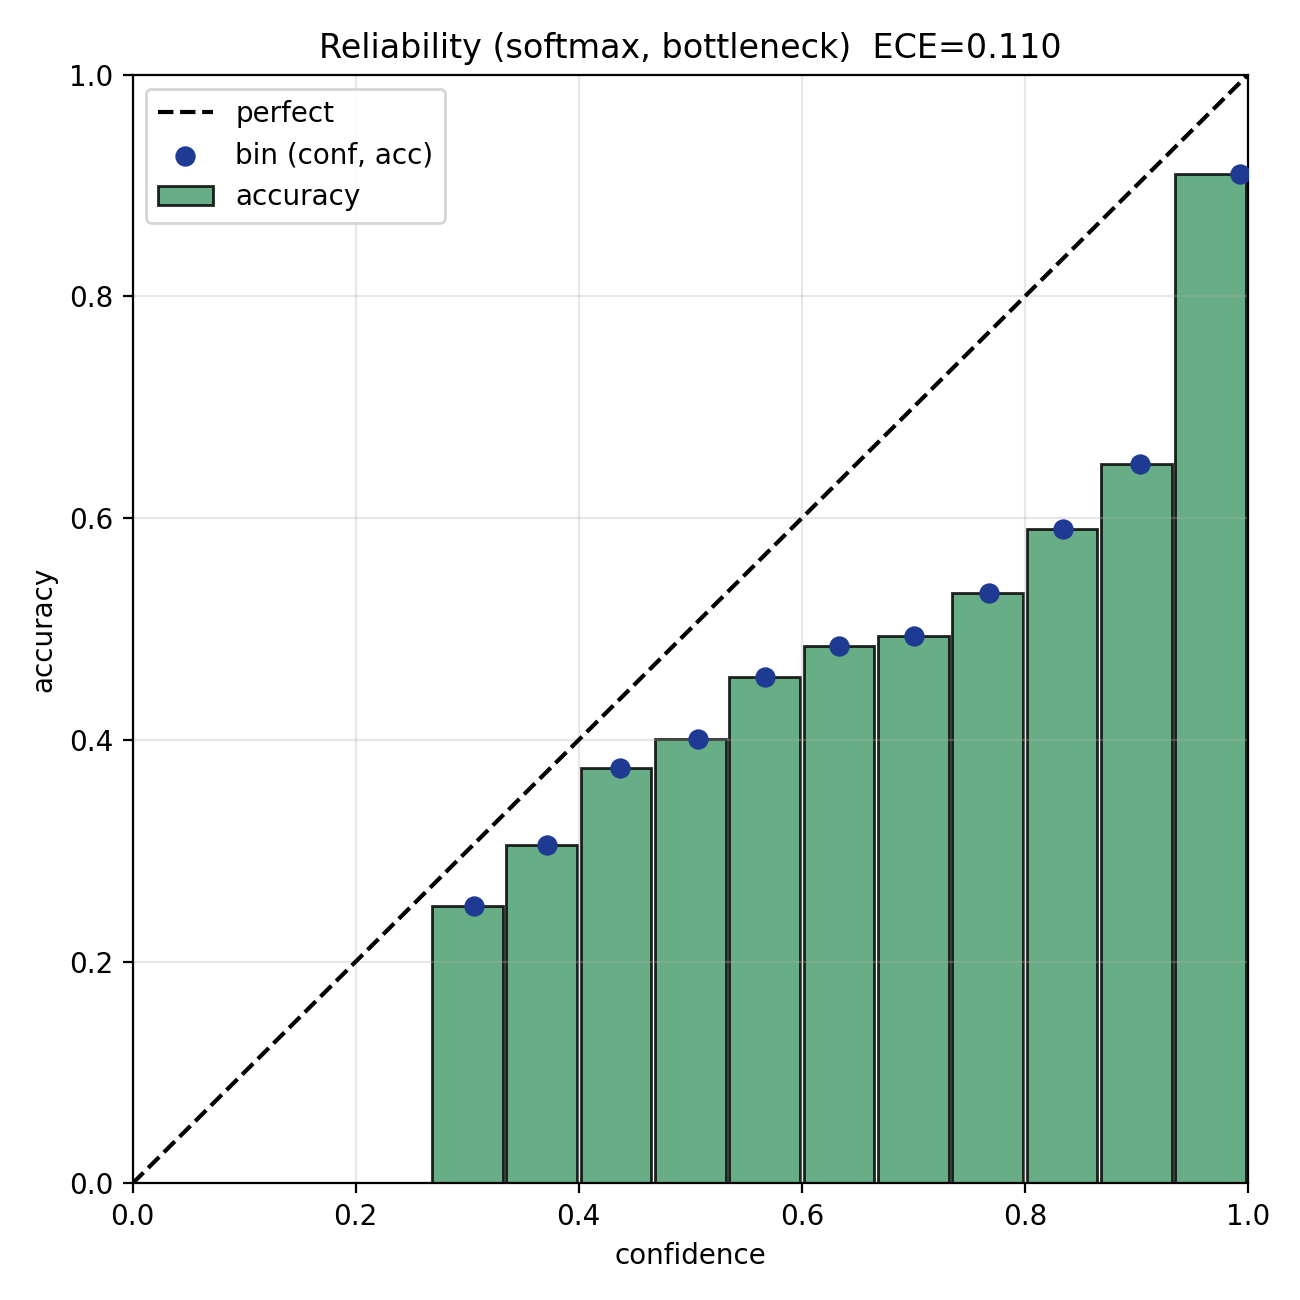

**bottleneck_softmax — ood_histogram**

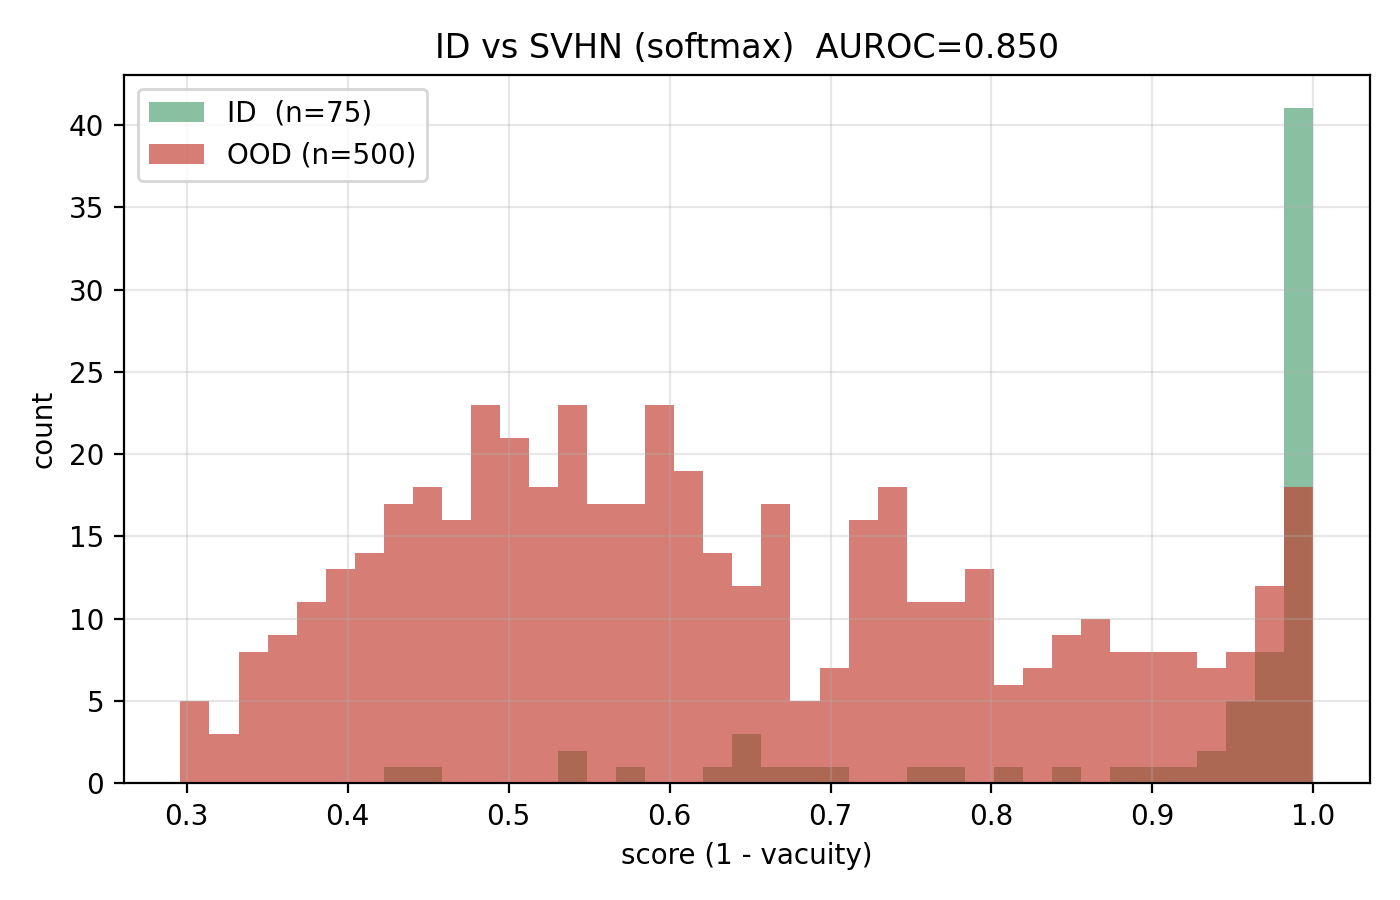

**bottleneck_softmax — confusion_matrix**

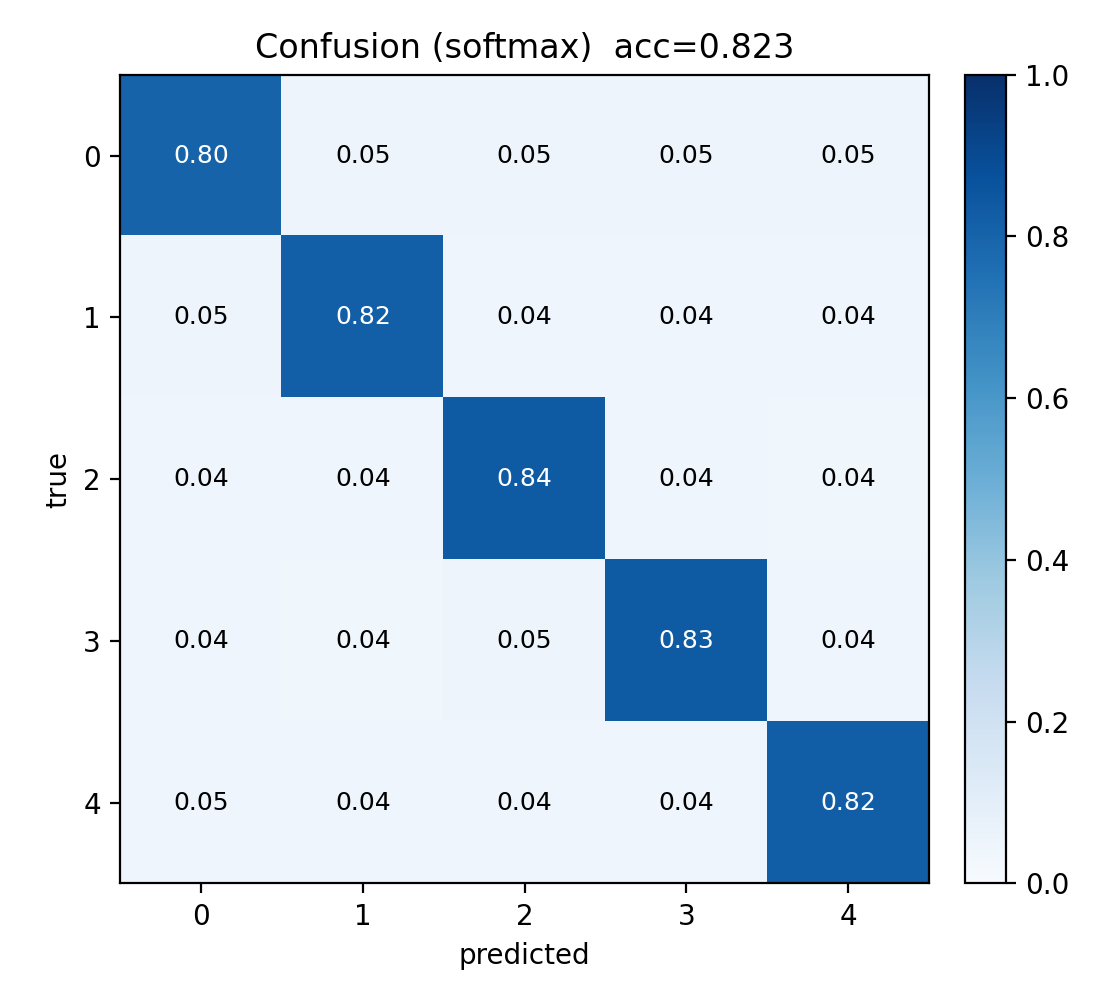

In [10]:
from IPython.display import Image, display, Markdown

artifacts = []
for tag in ["bottleneck_evidential", "bottleneck_softmax"]:
    for kind in ["reliability", "ood_histogram", "confusion_matrix"]:
        p = REPO / f"results/step3_{tag}_{kind}.png"
        if p.exists():
            artifacts.append((tag, kind, p))

for tag, kind, p in artifacts:
    display(Markdown(f"**{tag} — {kind}**"))
    display(Image(filename=str(p)))

## 9. W&B dashboard links

Each run printed its URL in the per-cell log above. If you're in `online` mode, the project landing page collects all four runs:

In [11]:
WANDB_ENTITY = None  # filled by wandb.login() — kept None to use default
project = "bpeft-thesis"
if WANDB_MODE == "online":
    try:
        api = wandb.Api()
        runs = api.runs(f"{project}", filters={"tags": {"$in": ["step3", "step3-eval"]}},
                         per_page=20)
        print("Step 3 runs in this project:")
        for r in runs:
            print(f"  - {r.name}  ({r.state})  {r.url}")
    except Exception as e:
        print(f"Could not list runs via API ({e!r}). Check the dashboard manually at:")
        print(f"   https://wandb.ai/<your-entity>/{project}")
elif WANDB_MODE == "offline":
    print("Offline mode: artifacts written under ./wandb/. Run `wandb sync wandb/`")
    print("to upload them after the fact.")
else:
    print("wandb was disabled for this session.")

Offline mode: artifacts written under ./wandb/. Run `wandb sync wandb/`
to upload them after the fact.


## 10. Exit-criteria checklist

| Spec requirement | Status |
|---|---|
| W&B dashboard with at least 2 runs (evidential + softmax) | **train + eval × 2 configs = 4 runs** (section 5 + 9) |
| Running the same config twice gives byte-identical `metrics.json` | section 6 (`filecmp.cmp` asserted) |
| Same 600 test episodes used regardless of who runs `evaluate` | section 3 + 5 — `configs/test_episodes.yaml` committed; both eval runs read from it |
| `pytest tests/` still passes | section 4 |

**What's now in place for Step 4:**

- `src/utils/seed.py` is the determinism hook every script calls first.
- `src/utils/wandb_utils.py::WandbRun` is the single logging surface — Step 4's episodic trainer just opens one run for the whole training loop and logs per-epoch instead of per-episode.
- `configs/test_episodes.yaml` is the canonical seed list. Step 4 (proper CIFAR-FS 64/16/20 split + episodic training) will re-use it untouched for the test split.
- `scripts/train.py` and `scripts/evaluate.py` are still the *only* CLI entry points — Step 4 extends them, doesn't replace them.

Step 3 is closed.